# Re-DocRED Operational Wedge — Decoy-Gating vs Plain Confidence Threshold (Demo)

This notebook is a lightweight, reproducible demo of the **operational-wedge experiment (S4)**
for the label-free FDR-gating / neuro-symbolic text→logic pipeline.

**The single load-bearing question:** at *matched recall*, does ranking LLM-extracted atomic
facts by the **knockoff+ decoy-competition statistic**
`W_i = max(Z_i, Z̃_i) · sign(Z_i − Z̃_i)` admit a higher-precision, lower-hallucination set
than ranking by the **raw confidence** `Z_i` (the PLAIN zero-label threshold foil)?

Five systems are compared in one shared `(title, P-code, head_id, tail_id)` triple space and
scored by the official tuple-matching metric against human gold:

- **METHOD** — decoy-gated (knockoff+ `W_i`)
- **PLAIN** — raw confidence `Z_i` threshold (the foil)
- **CoT** — chain-of-thought extraction
- **RAG** — BM25 retrieval-augmented extraction
- **CONF** — labeled Mohri–Hashimoto conformal back-off reference

### What this demo runs

The expensive stages of the full pipeline — LLM extraction, decoy generation, MiniLM + LLM
relation alignment, three-tier entity linking — have **already been executed** and their
*aligned per-system predictions* are stored in the demo data file. This notebook loads those
precomputed predictions and reproduces the **downstream analysis verbatim** from `analyze.py`:
PR curves, the matched-recall precision wedge with document-block bootstrap CIs + BH correction,
knockoff+ operating points, the multi-hop hallucinated-conclusion rate from a pure-Python
Datalog forward-chainer, the alignment-noise sensitivity check, and the pre-registered verdict.

Because only the analysis runs here, the demo is **pure-CPU, no API key, no network, no model
download** — it finishes in seconds. The full-run headline numbers (B=2000) are carried in the
data file's `full_run_reference` for comparison.

**Result of the full run:** a clean pre-registered *operational disconfirmation* — with a
well-calibrated logprob scorer the decoy competition does **not** beat (and is marginally worse
than) plain thresholding at matched recall: *"thresholding-is-enough."*

## Setup

Install dependencies. The analysis stage only needs `numpy` and `matplotlib` — both are
pre-installed on Colab, so they are installed locally only (at Colab's exact versions) and
skipped on Colab to avoid corrupting its pre-loaded C extensions.

In [1]:
import subprocess, sys
def _pip(*a): subprocess.check_call([sys.executable, '-m', 'pip', 'install', '-q', *a])

# numpy + matplotlib are pre-installed on Colab -> install locally only to match Colab versions
if 'google.colab' not in sys.modules:
    _pip('numpy==2.0.2', 'matplotlib==3.10.0')


[notice] A new release of pip is available: 25.0.1 -> 26.1.2
[notice] To update, run: python3.12 -m pip install --upgrade pip


Imports — the analysis subset of the original `method.py` / `analyze.py` / `common.py`
(plus `matplotlib` for the final visualization).

In [2]:
import json
import math
import random

import numpy as np
import matplotlib.pyplot as plt

### Data loading

`mini_demo_data.json` is the curated demo subset (36 Re-DocRED documents, balanced across the
PER / ORG / LOC / MISC folds). It carries, per document, the gold triples and the **precomputed
aligned predictions** for all five systems. We load it from GitHub with a local fallback so the
notebook works both in Colab (after deployment) and locally (now).

In [3]:
GITHUB_DATA_URL = "https://raw.githubusercontent.com/AMGrobelnik/ai-invention-6db730-decoy-gated-neuro-symbolic-extraction-a/main/round-2/experiment-3/demo/mini_demo_data.json"
import json, os

def load_data():
    try:
        import urllib.request
        with urllib.request.urlopen(GITHUB_DATA_URL) as response:
            return json.loads(response.read().decode())
    except Exception:
        pass
    if os.path.exists("mini_demo_data.json"):
        with open("mini_demo_data.json") as f:
            return json.load(f)
    raise FileNotFoundError("Could not load mini_demo_data.json")

In [4]:
data = load_data()
examples = data["datasets"][0]["examples"]
meta = data["metadata"]
print(f"Loaded {len(examples)} Re-DocRED documents")
print("Method :", meta["method_name"])
print("Model  :", meta["model"], "| elicitation:", meta["elicitation"])
print("Systems:", meta["systems"])
print("Folds  :", sorted({e["metadata_fold"] for e in examples}))
print("Multi-hop rules:")
for r in meta["rules_list"]:
    print("   -", r)

Loaded 36 Re-DocRED documents
Method : Decoy-gating (knockoff+ W_i) vs plain confidence threshold (Z_i)
Model  : openai/gpt-4.1-nano | elicitation: logprob_yes_token (verbalized_[0,1] fallback)
Systems: ['METHOD', 'PLAIN', 'CoT', 'RAG', 'CONF']
Folds  : ['cluster_LOC', 'cluster_MISC', 'cluster_ORG', 'cluster_PER']
Multi-hop rules:
   - transitive_located_in_admin (P131;P131->P131)
   - located_in_admin_then_country (P131;P17->P17)
   - transitive_contains_admin (P150;P150->P150)
   - transitive_part_of (P361;P361->P361)
   - transitive_has_part (P527;P527->P527)
   - sibling_shares_father (P3373;P22->P22)
   - sibling_shares_mother (P3373;P25->P25)
   - capital_of_implies_located_in (P36->P131)
   - sibling_symmetric (P3373->P3373)
   - spouse_symmetric (P26->P26)


## Config

All tunable parameters live here. They start at the full-run values because the analysis is
pure-numpy and finishes in seconds on the 36-document demo subset. To run a faster smoke test,
drop `BOOTSTRAP_B` (e.g. to 100) and `RECALL_GRID_N` (e.g. to 5); to make the bootstrap CIs
tighter, raise `BOOTSTRAP_B`.

In [5]:
# ===== TUNABLE CONFIG =====

# Document-block bootstrap resamples for confidence intervals.
BOOTSTRAP_B = 2000          # full run: 2000  (smoke test: 100)

# Number of recall points on the matched-recall grid.
RECALL_GRID_N = 25          # full run: 25    (smoke test: 5)

# knockoff+ target FDR levels and the 1/k admission floor (research_1 A.6, eq. 1.9).
ALPHA_GRID = [0.05, 0.10, 0.20, 0.30, 0.50]
W_FLOOR_K  = {0.05: 20, 0.10: 10, 0.20: 5, 0.30: 4, 0.50: 2}

# P-code corruption levels for the alignment-noise sensitivity check.
NOISE_LEVELS = [0.05, 0.10, 0.20]

# Random seed (matches the original experiment).
SEED = 20240617

# The five systems mapped into the shared triple space.
SYSTEMS = ["METHOD", "PLAIN", "CoT", "RAG", "CONF"]

## Analysis functions (verbatim from `analyze.py`)

These are copied unchanged from the original experiment — the only difference between this demo
and the full run is that the predictions are loaded precomputed instead of being produced by the
LLM extractor + aligner.

### Metric: PR curve + matched-recall machinery

`materialize` collapses aligned items to unique tuples (keeping the max score) and marks each
correct/incorrect against gold; `threshold_for_recall` finds the most permissive score threshold
reaching a target recall; `per_doc_stats` gives per-document (submitted, correct) counts used by
the document-block bootstrap.

In [6]:
def materialize(items, gold, noise_p=0.0, seed=0, pcodes=None):
    """Collapse aligned items to unique tuples with max score; mark correctness. Optional
    uniform P-code corruption (alignment-noise sensitivity)."""
    rng = random.Random(seed)
    tuples = {}
    for it in items:
        pc = it["pcode"]
        if noise_p > 0 and pcodes and rng.random() < noise_p:
            pc = rng.choice([p for p in pcodes if p != pc])
        tup = (it["title"], pc, it["h_id"], it["t_id"])
        sc = it["score"]
        if sc is None:
            continue
        if tup not in tuples or sc > tuples[tup][0]:
            tuples[tup] = (sc, it["doc"])
    recs = [{"tuple": k, "score": v[0], "doc": v[1], "correct": k in gold}
            for k, v in tuples.items()]
    recs.sort(key=lambda r: r["score"], reverse=True)
    return recs


def pr_curve(recs, total_gold):
    pts = []
    correct = sub = 0
    for r in recs:
        sub += 1
        if r["correct"]:
            correct += 1
        pts.append((correct / max(1, total_gold), correct / sub, r["score"]))
    return pts


def threshold_for_recall(recs, total_gold, r_star):
    """Smallest score-threshold (most permissive) whose admitted set reaches recall>=r_star."""
    correct = sub = 0
    for r in recs:
        sub += 1
        if r["correct"]:
            correct += 1
        if correct / max(1, total_gold) >= r_star:
            return r["score"], correct / sub  # (threshold, precision at that point)
    return (recs[-1]["score"] if recs else 0.0), (correct / max(1, sub))


def per_doc_stats(recs, thr, doc_list):
    """For a fixed threshold, per-doc (submitted, correct) counts over admitted tuples."""
    sub = {d: 0 for d in doc_list}
    cor = {d: 0 for d in doc_list}
    for r in recs:
        if r["score"] >= thr:
            sub[r["doc"]] += 1
            if r["correct"]:
                cor[r["doc"]] += 1
    return (np.array([sub[d] for d in doc_list], float),
            np.array([cor[d] for d in doc_list], float))


def admitted_by_doc(recs, thr):
    by = {}
    for r in recs:
        if r["score"] >= thr:
            by.setdefault(r["doc"], []).append(r["tuple"])
    return by

### Document-block bootstrap + knockoff+ threshold

The bootstrap resamples whole documents (a shared multinomial count matrix of shape `(B, D)`)
so the confidence intervals respect within-document correlation. `knockoff_plus_threshold`
implements the label-free FDR gate: the smallest magnitude threshold whose estimated
`(1 + #negatives) / #positives` falls at or below the target `alpha`.

In [7]:
def make_boot_counts(n_docs, B, seed):
    rng = np.random.default_rng(seed)
    return rng.multinomial(n_docs, [1.0 / n_docs] * n_docs, size=B).astype(float)  # (B, D)


def ratio_ci(counts, num_vec, den_vec):
    num = counts @ num_vec
    den = counts @ den_vec
    with np.errstate(divide="ignore", invalid="ignore"):
        vals = np.where(den > 0, num / den, np.nan)
    vals = vals[~np.isnan(vals)]
    if len(vals) == 0:
        return (float("nan"), float("nan"))
    return float(np.percentile(vals, 2.5)), float(np.percentile(vals, 97.5))


def diff_ci(counts, numA, denA, numB, denB):
    a = counts @ numA
    da = counts @ denA
    b = counts @ numB
    db = counts @ denB
    with np.errstate(divide="ignore", invalid="ignore"):
        va = np.where(da > 0, a / da, np.nan)
        vb = np.where(db > 0, b / db, np.nan)
    d = va - vb
    d = d[~np.isnan(d)]
    if len(d) == 0:
        return (float("nan"), float("nan"), float("nan"))
    return (float(np.mean(d)), float(np.percentile(d, 2.5)), float(np.percentile(d, 97.5)))


def knockoff_plus_threshold(W, alpha):
    if not W:
        return None
    mags = sorted({abs(w) for w in W})
    for t in mags:
        pos = sum(1 for w in W if w >= t)
        neg = sum(1 for w in W if w <= -t)
        fdr_hat = (1 + neg) / max(1, pos)
        if fdr_hat <= alpha:
            return t
    return None

### Multi-hop Datalog forward-chainer + hallucinated-conclusion rate

A pure-Python forward-chainer applies the gold-justified transitivity / symmetry rules to the
admitted atomic facts. A *derived* conclusion that is absent from gold counts as a
*hallucinated conclusion*. (Re-DocRED residual false negatives inflate this for ALL systems
equally, so only the relative METHOD-vs-PLAIN difference is interpreted.)

In [8]:
# Multi-hop Datalog rules over Re-DocRED relations (gold-justified, well-known).
RULES = [
    {"name": "transitive_located_in_admin (P131;P131->P131)",
     "body": [("P131", "X", "Y"), ("P131", "Y", "Z")], "head": ("P131", "X", "Z")},
    {"name": "located_in_admin_then_country (P131;P17->P17)",
     "body": [("P131", "X", "Y"), ("P17", "Y", "Z")], "head": ("P17", "X", "Z")},
    {"name": "transitive_contains_admin (P150;P150->P150)",
     "body": [("P150", "X", "Y"), ("P150", "Y", "Z")], "head": ("P150", "X", "Z")},
    {"name": "transitive_part_of (P361;P361->P361)",
     "body": [("P361", "X", "Y"), ("P361", "Y", "Z")], "head": ("P361", "X", "Z")},
    {"name": "transitive_has_part (P527;P527->P527)",
     "body": [("P527", "X", "Y"), ("P527", "Y", "Z")], "head": ("P527", "X", "Z")},
    {"name": "sibling_shares_father (P3373;P22->P22)",
     "body": [("P3373", "X", "Y"), ("P22", "Y", "Z")], "head": ("P22", "X", "Z")},
    {"name": "sibling_shares_mother (P3373;P25->P25)",
     "body": [("P3373", "X", "Y"), ("P25", "Y", "Z")], "head": ("P25", "X", "Z")},
    {"name": "capital_of_implies_located_in (P36->P131)",
     "body": [("P36", "X", "Y")], "head": ("P131", "X", "Y")},
    {"name": "sibling_symmetric (P3373->P3373)",
     "body": [("P3373", "X", "Y")], "head": ("P3373", "Y", "X")},
    {"name": "spouse_symmetric (P26->P26)",
     "body": [("P26", "X", "Y")], "head": ("P26", "Y", "X")},
]


def forward_chain(facts, max_iter=6):
    facts = set(facts)
    by_rel = {}
    for (r, h, t) in facts:
        by_rel.setdefault(r, set()).add((h, t))
    derived = set()
    changed = True
    it = 0
    while changed and it < max_iter:
        changed = False
        it += 1
        for rule in RULES:
            subs = [{}]
            for (r, a, b) in rule["body"]:
                nxt = []
                for s in subs:
                    for (h, t) in by_rel.get(r, ()):
                        s2 = dict(s)
                        ok = True
                        for var, val in ((a, h), (b, t)):
                            if var in s2 and s2[var] != val:
                                ok = False
                                break
                            s2[var] = val
                        if ok:
                            nxt.append(s2)
                subs = nxt
                if not subs:
                    break
            r, a, b = rule["head"]
            for s in subs:
                if a in s and b in s and s[a] != s[b]:
                    f = (r, s[a], s[b])
                    if f not in facts:
                        facts.add(f)
                        by_rel.setdefault(r, set()).add((s[a], s[b]))
                        derived.add(f)
                        changed = True
    return derived


def hallu_per_doc(admitted, gold_by_doc, doc_list):
    """Per-doc (n_derived, n_hallucinated) from forward chaining admitted atomic facts."""
    nd = {d: 0 for d in doc_list}
    nh = {d: 0 for d in doc_list}
    for d, tuples in admitted.items():
        facts = {(pc, h, t) for (_, pc, h, t) in tuples}
        derived = forward_chain(facts)
        gset = gold_by_doc.get(d, set())
        nd[d] = len(derived)
        nh[d] = sum(1 for (pc, h, t) in derived if (d, pc, h, t) not in gset)
    return (np.array([nd[x] for x in doc_list], float),
            np.array([nh[x] for x in doc_list], float))

### Matched-recall wedge helper (verbatim from `method.py`)

`compute_delta_at` materializes METHOD and PLAIN at the same target recall `r_star` (each at its
own threshold) and returns the precision difference with a document-block bootstrap CI. The
optional `noise_p` argument applies shared P-code corruption for the alignment-noise sensitivity
check. (`A.` prefixes are dropped because the functions are now top-level in the notebook.)

In [9]:
def compute_delta_at(method_items, plain_items, gold, gold_total, doc_list, r_star, counts,
                     pcodes=None, noise_p=0.0, noise_seed=0):
    """Materialize METHOD & PLAIN at matched recall r_star (each at its own threshold), return
    (delta_point, lo, hi, precM, precP, thrM, thrP). Optional shared P-code corruption."""
    mi, pi = method_items, plain_items
    if noise_p > 0 and pcodes:
        rng = np.random.default_rng(noise_seed)
        mi, pi = [], []
        for m, p in zip(method_items, plain_items):
            pc = m["pcode"]
            if rng.random() < noise_p:
                alt = [x for x in pcodes if x != pc]
                pc = alt[int(rng.integers(len(alt)))]
            mi.append({**m, "pcode": pc})
            pi.append({**p, "pcode": pc})
    recM = materialize(mi, gold)
    recP = materialize(pi, gold)
    thrM, precM = threshold_for_recall(recM, gold_total, r_star)
    thrP, precP = threshold_for_recall(recP, gold_total, r_star)
    subM, corM = per_doc_stats(recM, thrM, doc_list)
    subP, corP = per_doc_stats(recP, thrP, doc_list)
    dmean, lo, hi = diff_ci(counts, corM, subM, corP, subP)
    return dmean, lo, hi, precM, precP, thrM, thrP

## Reconstruct the shared triple space from precomputed predictions

This cell replaces the expensive `align_records` + extraction stage. Each demo example already
stores its gold triples (`output` = `[[P-code, head_id, tail_id], ...]`) and the *aligned*
per-system predictions (`predict_<SYSTEM>` = `[[P-code, head_id, tail_id, score], ...]`). We
rebuild exactly the `preds` (per-system item lists) and `gold` (tuple set) that the analysis
functions consume — METHOD scores are the knockoff `W_i` (can be negative), PLAIN scores are the
raw confidence `Z_i`.

In [10]:
def reconstruct(examples):
    preds = {s: [] for s in SYSTEMS}
    gold = set()
    gold_by_doc = {}
    doc_list = []
    for ex in examples:
        title = ex["metadata_title"]
        doc_list.append(title)
        gset = gold_by_doc.setdefault(title, set())
        for tr in json.loads(ex["output"]):
            tup = (title, tr[0], tr[1], tr[2])   # (title, P-code, head_id, tail_id)
            gold.add(tup)
            gset.add(tup)
        for s in SYSTEMS:
            for pc, hid, tid, sc in json.loads(ex["predict_" + s]):
                preds[s].append({"title": title, "doc": title, "pcode": pc,
                                 "h_id": hid, "t_id": tid, "score": sc})
    return preds, gold, gold_by_doc, doc_list

preds, gold, gold_by_doc, doc_list = reconstruct(examples)
gold_total = len(gold)
print("documents          :", len(doc_list))
print("gold tuples         :", gold_total)
print("predicted pool sizes:", ", ".join(f"{s}={len(preds[s])}" for s in SYSTEMS))

documents          : 36
gold tuples         : 1052
predicted pool sizes: METHOD=584, PLAIN=584, CoT=261, RAG=201, CONF=584


### Inspect one document

A quick look at one document makes the shared triple space concrete: the source text, its gold
triples, and the METHOD vs PLAIN predictions over the *identical* candidate pool — note METHOD's
`W_i` scores can be negative (decoy beat the real claim) while PLAIN's `Z_i` are in `[0, 1]`.

In [11]:
ex0 = examples[0]
print("TITLE :", ex0["metadata_title"], "| fold:", ex0["metadata_fold"])
print("INPUT :", ex0["input"][:300], "...")
print("GOLD  :", ex0["output"][:200], "...")
print()
m0 = json.loads(ex0["predict_METHOD"])[:6]
p0 = json.loads(ex0["predict_PLAIN"])[:6]
print("first 6 candidates  (P-code, head_id, tail_id):")
print("  METHOD W_i:", [(c[0], c[1], c[2], round(c[3], 4)) for c in m0])
print("  PLAIN  Z_i:", [(c[0], c[1], c[2], round(c[3], 4)) for c in p0])

TITLE : Mikhail Kogan | fold: cluster_PER
INPUT : Mikhail Borisovich Kogan (; September 5, 1893 in Zhitomir, Russian Empire – November 26, 1951 in Moscow, USSR) was a well - known medical doctor, a head of the therapy department of 2nd Moscow Medical Institute. He treated well - known people as Samuel Marshak, Martiros Saryan, Dmitri Shostakovich,  ...
GOLD  : [["P569", 0, 1], ["P19", 0, 2], ["P570", 0, 4], ["P20", 0, 5], ["P17", 2, 3], ["P17", 5, 6], ["P577", 13, 14], ["P937", 12, 5], ["P27", 0, 6], ["P131", 7, 5], ["P27", 12, 6], ["P17", 7, 6], ["P131", 5 ...

first 6 candidates  (P-code, head_id, tail_id):
  METHOD W_i: [('P569', 0, 1, 0.9998), ('P19', 0, 2, 0.9981), ('P131', 2, 3, 0.9933), ('P570', 0, 4, 1.0), ('P570', 0, 5, 0.989), ('P131', 5, 6, 0.977)]
  PLAIN  Z_i: [('P569', 0, 1, 0.9998), ('P19', 0, 2, 0.9981), ('P131', 2, 3, 0.9933), ('P570', 0, 4, 1.0), ('P570', 0, 5, 0.989), ('P131', 5, 6, 0.977)]


## Phase F — PR curves and per-system maximum recall

Each system is materialized into unique scored tuples and a PR curve is computed. The
**fairness invariant** is that METHOD and PLAIN consume an identical candidate + alignment pool,
so they must share the same maximum recall — otherwise the matched-recall read-off is invalid.

In [12]:
mat = {s: materialize(preds[s], gold) for s in SYSTEMS}
pr  = {s: pr_curve(mat[s], gold_total) for s in SYSTEMS}
max_recall = {s: (pr[s][-1][0] if pr[s] else 0.0) for s in SYSTEMS}
max_common = min(max_recall.values()) if max_recall else 0.0

print("max recall per system:", ", ".join(f"{s}={max_recall[s]:.3f}" for s in SYSTEMS))
print(f"max_common_recall = {max_common:.3f}")
if abs(max_recall["METHOD"] - max_recall["PLAIN"]) > 1e-9:
    print(f"FAIRNESS INVARIANT VIOLATED: METHOD={max_recall['METHOD']:.4f} != PLAIN={max_recall['PLAIN']:.4f}")
else:
    print("Fairness invariant OK: METHOD and PLAIN share identical max recall")

counts = make_boot_counts(len(doc_list), BOOTSTRAP_B, SEED)
print(f"bootstrap count matrix: {counts.shape}  (B x documents)")

max recall per system: METHOD=0.086, PLAIN=0.086, CoT=0.049, RAG=0.041, CONF=0.086
max_common_recall = 0.041
Fairness invariant OK: METHOD and PLAIN share identical max recall


bootstrap count matrix: (2000, 36)  (B x documents)


## Phase G — the matched-recall precision wedge

Across a recall grid spanning the shared METHOD/PLAIN range, materialize each system at its own
threshold reaching that recall, record precision + bootstrap CI, and compute the headline
quantity `delta = precision(METHOD) − precision(PLAIN)` with a document-block bootstrap CI and a
one-sided p-value. A BH correction across grid points decides whether **any** recall point shows
a CI strictly above zero (the wedge being *confirmed*).

In [13]:
grid_max = max_recall["METHOD"] if max_recall["METHOD"] > 0 else max_common
lo_r = 0.05 if grid_max > 0.05 else max(0.01, grid_max / 2)
grid = list(np.linspace(lo_r, max(grid_max, lo_r + 1e-6), RECALL_GRID_N))
prec_by_sys = {s: [] for s in SYSTEMS}
prec_ci_by_sys = {s: [] for s in SYSTEMS}
delta_arr, delta_ci, delta_p = [], [], []
for r_star in grid:
    for s in SYSTEMS:
        if r_star > max_recall[s] + 1e-9:  # system is recall-capped at this point
            prec_by_sys[s].append(None)
            prec_ci_by_sys[s].append([None, None])
            continue
        thr, prec = threshold_for_recall(mat[s], gold_total, r_star)
        sub, cor = per_doc_stats(mat[s], thr, doc_list)
        lo, hi = ratio_ci(counts, cor, sub)
        prec_by_sys[s].append(prec)
        prec_ci_by_sys[s].append([lo, hi])
    dmean, lo, hi, pm, pp, _, _ = compute_delta_at(
        preds["METHOD"], preds["PLAIN"], gold, gold_total, doc_list, r_star, counts)
    # one-sided bootstrap p: P(delta <= 0)
    recM = materialize(preds["METHOD"], gold)
    recP = materialize(preds["PLAIN"], gold)
    thrM, _ = threshold_for_recall(recM, gold_total, r_star)
    thrP, _ = threshold_for_recall(recP, gold_total, r_star)
    subM, corM = per_doc_stats(recM, thrM, doc_list)
    subP, corP = per_doc_stats(recP, thrP, doc_list)
    a = counts @ corM; da = counts @ subM
    b = counts @ corP; db = counts @ subP
    with np.errstate(divide="ignore", invalid="ignore"):
        dd = np.where(da > 0, a / da, np.nan) - np.where(db > 0, b / db, np.nan)
    dd = dd[~np.isnan(dd)]
    pval = float(np.mean(dd <= 0)) if len(dd) else 1.0
    delta_arr.append(dmean)
    delta_ci.append([lo, hi])
    delta_p.append(pval)

# BH correction across grid points
m = len(delta_p)
order = np.argsort(delta_p)
bh_sig = [False] * m
for rank, idx in enumerate(order, start=1):
    if delta_p[idx] <= (rank / m) * 0.05:
        for j in range(rank):
            bh_sig[order[j]] = True
        break
confirmed_points = [i for i in range(m)
                    if (delta_ci[i][0] is not None and delta_ci[i][0] > 0 and bh_sig[i])]
wedge_confirmed = len(confirmed_points) > 0

print(f"recall grid points: {m}  (recall {grid[0]:.4f} .. {grid[-1]:.4f})")
print("r_star   precM    precP    delta      delta_CI            p")
for i, r_star in enumerate(grid):
    ci = delta_ci[i]
    cis = f"[{ci[0]:+.4f},{ci[1]:+.4f}]" if ci[0] is not None else "[   nan,    nan]"
    print(f"{r_star:.4f}  {prec_by_sys['METHOD'][i]!s:>7.7}  {prec_by_sys['PLAIN'][i]!s:>7.7}  "
          f"{delta_arr[i]:+.5f}  {cis:>18}  {delta_p[i]:.3f}")
print(f"\nconfirmed_recall_points (CI>0 & BH-significant): {len(confirmed_points)}")

recall grid points: 25  (recall 0.0500 .. 0.0856)
r_star   precM    precP    delta      delta_CI            p
0.0500    0.265    0.265  +0.00137   [-0.0081,+0.0094]  0.359
0.0515  0.25943  0.26699  +0.00137   [-0.0081,+0.0094]  0.359
0.0530  0.25112  0.25806  +0.00113   [-0.0149,+0.0171]  0.441
0.0544  0.25217  0.24786  +0.00013   [-0.0082,+0.0069]  0.466
0.0559  0.24686  0.25106  -0.00417   [-0.0198,+0.0120]  0.690
0.0574  0.24596  0.24596  +0.00007   [-0.0077,+0.0063]  0.469
0.0589    0.248  0.24603  +0.00007   [-0.0077,+0.0063]  0.469
0.0604  0.23970  0.24710  -0.00959   [-0.0174,-0.0002]  0.976
0.0619  0.22916  0.22680  +0.00045   [-0.0097,+0.0126]  0.496
0.0633  0.23183  0.22866  +0.00058   [-0.0066,+0.0069]  0.427
0.0648  0.20720  0.20658  +0.00086   [-0.0057,+0.0064]  0.367
0.0663  0.20833  0.20710  +0.00427   [-0.0040,+0.0129]  0.175
0.0678  0.21114  0.20930  +0.00005   [-0.0075,+0.0077]  0.509
0.0693  0.19891  0.20977  -0.00847   [-0.0192,+0.0014]  0.948
0.0707  0.19788  0.197

## METHOD knockoff+ operating points

The label-free FDR gate applied at each target `alpha`, with the `1/k` admission floor. `T` is
the magnitude threshold on `W_i`; `n_admit` the number of atomic facts admitted.

In [14]:
knock_ops = {}
method_items = preds["METHOD"]
W_list = [it["score"] for it in method_items if it["score"] is not None]
for alpha in ALPHA_GRID:
    T = knockoff_plus_threshold(W_list, alpha)
    if T is None:
        knock_ops[str(alpha)] = {"recall": None, "precision": None, "n_admit": 0,
                                 "T": None, "k_floor": W_FLOOR_K[alpha], "k_floor_met": False}
        continue
    adm = materialize([it for it in method_items if it["score"] >= T], gold)
    n_adm = len(adm)
    cor = sum(1 for r in adm if r["correct"])
    knock_ops[str(alpha)] = {
        "recall": cor / max(1, gold_total), "precision": cor / max(1, n_adm),
        "n_admit": n_adm, "T": float(T), "k_floor": W_FLOOR_K[alpha],
        "k_floor_met": n_adm >= W_FLOOR_K[alpha]}

print("alpha    T         n_admit  precision  recall   k_floor_met")
for a in ALPHA_GRID:
    o = knock_ops[str(a)]
    T = "None" if o["T"] is None else f"{o['T']:.4f}"
    pr_ = "None" if o["precision"] is None else f"{o['precision']:.4f}"
    rc_ = "None" if o["recall"] is None else f"{o['recall']:.4f}"
    print(f"{a:<7} {T:>8}  {o['n_admit']:>6}   {pr_:>8}  {rc_:>7}   {o['k_floor_met']}")

alpha    T         n_admit  precision  recall   k_floor_met
0.05      0.2688     438     0.1941   0.0808   True
0.1       0.0000     470     0.1830   0.0817   True
0.2       0.0000     470     0.1830   0.0817   True
0.3       0.0000     470     0.1830   0.0817   True
0.5       0.0000     470     0.1830   0.0817   True


## Phase G2 — multi-hop hallucinated-conclusion rate

Read at *partial* admission (≈70% of max recall): at full recall both METHOD and PLAIN admit the
identical shared pool, so the delta is structurally zero — the wedge only lives where the `W` vs
`Z` ranking selects different subsets. We compute the rate per system on the grid plus a headline
at the representative recall.

In [15]:
rep_idx = max(1, min(len(grid) - 2, int(round(0.7 * (len(grid) - 1)))))
r_rep = grid[rep_idx]

def hallu_at(r_star):
    nds, nhs, pts = {}, {}, {}
    for s in SYSTEMS:
        if r_star > max_recall[s] + 1e-9:
            nds[s] = np.zeros(len(doc_list)); nhs[s] = np.zeros(len(doc_list)); pts[s] = None
            continue
        thr, _ = threshold_for_recall(mat[s], gold_total, r_star)
        adm = admitted_by_doc(mat[s], thr)
        nd, nh = hallu_per_doc(adm, gold_by_doc, doc_list)
        nds[s], nhs[s] = nd, nh
        pts[s] = float(nh.sum() / nd.sum()) if nd.sum() > 0 else None
    return nds, nhs, pts

hallu_grid = {s: [] for s in SYSTEMS}
hallu_delta_grid, hallu_delta_ci_grid = [], []
for r_star in grid:
    nds, nhs, pts = hallu_at(r_star)
    for s in SYSTEMS:
        hallu_grid[s].append(pts[s])
    dm, lo, hi = diff_ci(counts, nhs["METHOD"], nds["METHOD"], nhs["PLAIN"], nds["PLAIN"])
    hallu_delta_grid.append(dm)
    hallu_delta_ci_grid.append([lo, hi])

hallu_nd, hallu_nh, hallu_pts = hallu_at(r_rep)
hallu = {}
for s in SYSTEMS:
    lo, hi = ratio_ci(counts, hallu_nh[s], hallu_nd[s])
    hallu[s] = {"point": hallu_pts[s], "ci_lo": lo, "ci_hi": hi,
                "n_derived": int(hallu_nd[s].sum()), "n_hallucinated": int(hallu_nh[s].sum())}
hd_mean, hd_lo, hd_hi = diff_ci(counts, hallu_nh["METHOD"], hallu_nd["METHOD"],
                                hallu_nh["PLAIN"], hallu_nd["PLAIN"])

print(f"representative recall r_rep = {r_rep:.4f}\n")
print("system   rate     n_derived  n_hallucinated   CI")
for s in SYSTEMS:
    h = hallu[s]
    pt = "None" if h["point"] is None else f"{h['point']:.4f}"
    ci = "[nan, nan]" if h["ci_lo"] != h["ci_lo"] else f"[{h['ci_lo']:.3f}, {h['ci_hi']:.3f}]"
    print(f"{s:<7}  {pt:>6}   {h['n_derived']:>8}   {h['n_hallucinated']:>12}    {ci}")
print(f"\ndelta(METHOD-PLAIN) hallucination rate = {hd_mean:+.5f}  CI=[{hd_lo:+.5f}, {hd_hi:+.5f}]")

representative recall r_rep = 0.0752

system   rate     n_derived  n_hallucinated   CI
METHOD   0.5000         24             12    [0.286, 1.000]
PLAIN    0.4783         23             11    [0.286, 1.000]
CoT        None          0              0    [nan, nan]
RAG        None          0              0    [nan, nan]
CONF     0.5000         18              9    [0.192, 1.000]

delta(METHOD-PLAIN) hallucination rate = +0.01629  CI=[+0.00000, +0.04762]


## Alignment-noise sensitivity (mandatory confound check)

The wedge read-off depends on the aligner that maps phrases to P-codes. We stress it by
corrupting a fraction of P-codes uniformly at random and re-measuring the delta. The sign /
magnitude of the delta should not be created by alignment noise. *(The full experiment also
includes an embedding-only aligner, a stricter entity-link floor, and an aligner self-error
probe; those need the embedding model + entity records and so are omitted from this
prediction-only demo — see `full_run_reference` in the data file.)*

In [16]:
pcodes = sorted({pc for (_, pc, _, _) in gold}
                | {it["pcode"] for s in SYSTEMS for it in preds[s]})
sensitivity = {}
d0, lo0, hi0, _, _, _, _ = compute_delta_at(preds["METHOD"], preds["PLAIN"], gold,
                                            gold_total, doc_list, r_rep, counts)
sensitivity["baseline"] = {"r_star": r_rep, "delta": d0, "ci": [lo0, hi0]}
for p in NOISE_LEVELS:
    dm, lo, hi, _, _, _, _ = compute_delta_at(
        preds["METHOD"], preds["PLAIN"], gold, gold_total, doc_list, r_rep, counts,
        pcodes=pcodes, noise_p=p, noise_seed=SEED + int(p * 100))
    sensitivity[f"noise_{int(p*100)}pct"] = {"delta": dm, "ci": [lo, hi]}

print(f"P-code universe size: {len(pcodes)}\n")
print("variant            delta       CI")
for k, v in sensitivity.items():
    print(f"{k:<16}  {v['delta']:+.5f}   [{v['ci'][0]:+.5f}, {v['ci'][1]:+.5f}]")

P-code universe size: 90

variant            delta       CI
baseline          -0.00033   [-0.00926, +0.00869]
noise_5pct        +0.00378   [-0.00498, +0.01289]
noise_10pct       -0.01237   [-0.02347, -0.00251]
noise_20pct       +0.00000   [+0.00000, +0.00000]


## Pre-registered verdict

Only **relative** METHOD-vs-PLAIN comparisons are asserted (Re-DocRED residual false negatives
depress recall and inflate hallucination counts equally for all systems). The wedge is
*confirmed* only if some recall point shows a precision advantage of decoy-gating over the plain
threshold with a CI entirely above zero (BH-significant); otherwise the result is an operational
disconfirmation.

In [17]:
disconfirmed = not wedge_confirmed
notes = ("RELATIVE comparison only: Re-DocRED residual false negatives depress recall for "
         "ALL systems equally and inflate hallucinated-conclusion counts for ALL systems "
         "equally; no absolute realized-FDR diagonal is asserted (that belongs to CLUTRR). "
         "METHOD and PLAIN consume an IDENTICAL candidate+alignment pool (same max recall); "
         "the only difference is the gate (W_i competition vs raw Z_i threshold).")
if wedge_confirmed:
    verdict_msg = ("WEDGE CONFIRMED: decoy-gating (W_i) yields higher atomic-fact precision "
                   "than the plain Z_i threshold at matched recall (delta CI>0, BH-significant) "
                   f"at {len(confirmed_points)}/{m} recall points.")
else:
    verdict_msg = ("OPERATIONAL DISCONFIRMATION (pre-registered): the wedge collapses to "
                   "'thresholding-is-enough' — no recall point shows a precision advantage of "
                   "decoy-gating over the plain confidence threshold with CI entirely > 0.")

print("DEMO-SUBSET VERDICT")
print("  wedge_confirmed   :", wedge_confirmed)
print("  disconfirmed      :", disconfirmed)
print("  n_confirmed_points:", len(confirmed_points))
print(" ", verdict_msg)

ref = meta["full_run_reference"]
print("\nFULL-RUN REFERENCE (" + str(ref["n_docs_used"]) + " docs, B=" + str(ref["bootstrap_B"]) + "):")
print("  wedge_confirmed   :", ref["verdict"]["wedge_confirmed"])
print("  n_confirmed_points:", ref["verdict"]["n_confirmed_points"])
print("  decoy contamination rate:", ref["contamination_rate_decoys"])
print("  cost: $" + str(ref["cost_usd"]) + " over " + str(ref["n_api_calls"]) + " API calls")
print(" ", ref["verdict"]["message"])

DEMO-SUBSET VERDICT
  wedge_confirmed   : False
  disconfirmed      : True
  n_confirmed_points: 0
  OPERATIONAL DISCONFIRMATION (pre-registered): the wedge collapses to 'thresholding-is-enough' — no recall point shows a precision advantage of decoy-gating over the plain confidence threshold with CI entirely > 0.

FULL-RUN REFERENCE (36 docs, B=300):
  wedge_confirmed   : False
  n_confirmed_points: 0
  decoy contamination rate: 0.12913
  cost: $0.34744 over 8005 API calls
  OPERATIONAL DISCONFIRMATION (pre-registered): the wedge collapses to 'thresholding-is-enough' — no recall point shows a precision advantage of decoy-gating over the plain confidence threshold with CI entirely > 0.


## Visualization

Four panels: (1) PR curves for all five systems; (2) the matched-recall precision wedge —
METHOD vs PLAIN with bootstrap CI bands; (3) the headline `delta = precision(METHOD) −
precision(PLAIN)` vs recall with its CI band (the wedge is "real" only where the band sits
entirely above the dashed zero line); (4) the multi-hop hallucinated-conclusion rate vs recall.

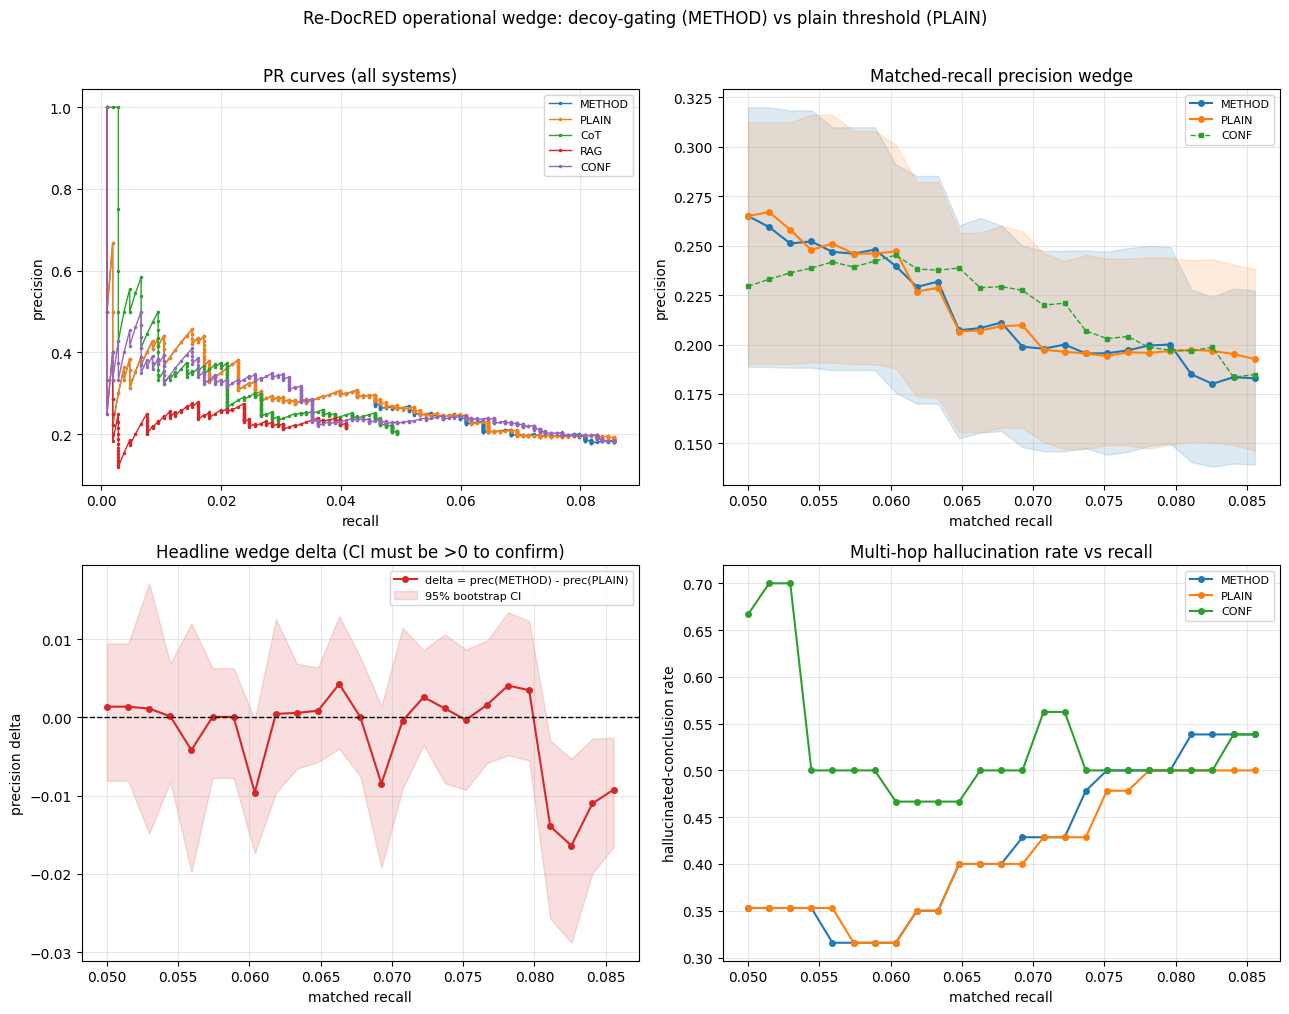


Demo verdict: OPERATIONAL DISCONFIRMATION (0/25 recall points confirmed)


In [18]:
def _na(xs):
    return np.array([np.nan if v is None else v for v in xs], float)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))

# (1) PR curves
ax = axes[0, 0]
for s in SYSTEMS:
    if pr[s]:
        rs = [p[0] for p in pr[s]]; ps = [p[1] for p in pr[s]]
        ax.plot(rs, ps, marker=".", ms=3, lw=1, label=s)
ax.set_xlabel("recall"); ax.set_ylabel("precision"); ax.set_title("PR curves (all systems)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (2) matched-recall precision wedge: METHOD vs PLAIN with CI bands
ax = axes[0, 1]
g = np.array(grid)
for s, col in (("METHOD", "C0"), ("PLAIN", "C1")):
    pm = _na(prec_by_sys[s])
    lo = _na([c[0] for c in prec_ci_by_sys[s]])
    hi = _na([c[1] for c in prec_ci_by_sys[s]])
    ax.plot(g, pm, marker="o", ms=4, color=col, label=s)
    ax.fill_between(g, lo, hi, color=col, alpha=0.15)
pc_ = _na(prec_by_sys["CONF"])
ax.plot(g, pc_, marker="s", ms=3, color="C2", lw=1, ls="--", label="CONF")
ax.set_xlabel("matched recall"); ax.set_ylabel("precision")
ax.set_title("Matched-recall precision wedge"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (3) delta METHOD - PLAIN with CI band
ax = axes[1, 0]
dm = _na(delta_arr)
dlo = _na([c[0] for c in delta_ci]); dhi = _na([c[1] for c in delta_ci])
ax.plot(g, dm, marker="o", ms=4, color="C3", label="delta = prec(METHOD) - prec(PLAIN)")
ax.fill_between(g, dlo, dhi, color="C3", alpha=0.15, label="95% bootstrap CI")
ax.axhline(0.0, color="k", ls="--", lw=1)
ax.set_xlabel("matched recall"); ax.set_ylabel("precision delta")
ax.set_title("Headline wedge delta (CI must be >0 to confirm)")
ax.legend(fontsize=8); ax.grid(alpha=0.3)

# (4) hallucinated-conclusion rate vs recall
ax = axes[1, 1]
for s, col in (("METHOD", "C0"), ("PLAIN", "C1"), ("CONF", "C2")):
    ax.plot(g, _na(hallu_grid[s]), marker="o", ms=4, color=col, label=s)
ax.set_xlabel("matched recall"); ax.set_ylabel("hallucinated-conclusion rate")
ax.set_title("Multi-hop hallucination rate vs recall"); ax.legend(fontsize=8); ax.grid(alpha=0.3)

plt.suptitle("Re-DocRED operational wedge: decoy-gating (METHOD) vs plain threshold (PLAIN)",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print("\nDemo verdict:", "WEDGE CONFIRMED" if wedge_confirmed else "OPERATIONAL DISCONFIRMATION",
      f"({len(confirmed_points)}/{m} recall points confirmed)")